## PTID-AI-MAR-26-1134_AI-Client-Project-2

#### Install Dependencies

In [41]:
!pip install -U pip setuptools wheel

In [42]:
!pip install -U ultralytics albumentations opencv-python matplotlib seaborn tqdm pyyaml

#### Import Libraries

In [43]:
# %%
import os
import shutil
from glob import glob
from pathlib import Path
import numpy as np
import cv2
import random
import yaml
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import csv

#### Seed Configuration

In [44]:

def seed_everything(seed=42):
    import torch
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

In [45]:
seed_everything(42)

#### Dataset Configuration

In [46]:
# ---------- Paths ----------
ROOT = Path(".").resolve()
SRC_ROOT = Path("/kaggle/input/datasets/rupankarmajumdar/crop-pests-dataset")  # source (read-only)
OUT = ROOT / "yolo_dataset"  # destination (writable)

In [47]:
IMG_DIRS = {
    "train": OUT / "train" / "images",
    "val":   OUT / "val"   / "images",
    "test":  OUT / "test"  / "images",
}

In [48]:
LABEL_DIRS = {
    "train": OUT / "train" / "labels",
    "val":   OUT / "val"   / "labels",
    "test":  OUT / "test"  / "labels",
}

In [49]:
for d in list(IMG_DIRS.values()) + list(LABEL_DIRS.values()):
    d.mkdir(parents=True, exist_ok=True)

#### Data Class Names

In [50]:
CLASS_NAMES = [
    "Ants","Bees","Beetles","Caterpillars","Earthworms","Earwigs",
    "Grasshoppers","Moths","Slugs","Snails","Wasps","Weevils"
]

In [51]:
NUM_CLASSES = len(CLASS_NAMES)

### Data Preprocessing

#### Image Label Pair Collection

In [52]:
def collect_pairs_src(src_img_dir, src_label_dir, exts_img=[".png",".jpg",".jpeg"], exts_mask_img=[".png",".jpg",".jpeg"]):
    imgs = []
    for e in exts_img:
        imgs.extend(sorted(glob(str(src_img_dir / f"*{e}"))))
    pairs = []
    for img in imgs:
        name = Path(img).stem
        txt_path = None
        p = src_label_dir / (name + ".txt")
        if p.exists():
            txt_path = str(p)
        mask_path = None
        if txt_path is None:
            for e in exts_mask_img:
                p2 = src_label_dir / (name + e)
                if p2.exists():
                    mask_path = str(p2)
                    break
        pairs.append((str(img), txt_path, mask_path))
    return pairs

#### Image Mask Indicing

In [53]:
def read_mask_as_indices(mask_path, num_classes=NUM_CLASSES):
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None:
        return None
    if len(m.shape) == 2:
        return m.astype(np.uint8)
    # try channels as indices (R,G,B)
    for ch in (2,1,0):
        c = m[:,:,ch]
        uniques = np.unique(c)
        if uniques.max() <= 255 and len(uniques) <= max(256, num_classes*4):
            return c.astype(np.uint8)
    # palette: map unique RGB colors -> index
    h,w,c = m.shape
    flat = m.reshape(-1, c)
    uniques, inv = np.unique(flat, axis=0, return_inverse=True)
    if uniques.shape[0] <= 256:
        return inv.reshape(h, w).astype(np.uint8)
    # fallback: grayscale
    gray = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    return gray.astype(np.uint8)

#### Masks To Bounding Boxes

In [54]:
def mask_to_bboxes(mask, min_area=20, background_vals=(0,)):
    bboxes = []
    if mask is None:
        return bboxes
    unique_vals = np.unique(mask)
    for val in unique_vals:
        if int(val) in background_vals:
            continue
        cls = int(val)
        if cls < 0 or cls >= NUM_CLASSES:
            continue
        m = (mask == val).astype('uint8')
        if m.sum() == 0:
            continue
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(m, connectivity=8)
        for i in range(1, num_labels):
            x, y, w, h, area = stats[i]
            if area < min_area:
                continue
            cx = x + w / 2.0
            cy = y + h / 2.0
            bboxes.append((cls, cx, cy, w, h))
    return bboxes

#### Writing Labels

In [55]:
def write_yolo_label(txt_path, bboxes, img_w, img_h):
    lines = []
    for (cls, cx, cy, w, h) in bboxes:
        x_center = cx / img_w
        y_center = cy / img_h
        w_n = w / img_w
        h_n = h / img_h
        lines.append(f"{int(cls)} {x_center:.6f} {y_center:.6f} {w_n:.6f} {h_n:.6f}")
    with open(txt_path, "w") as f:
        f.write("\n".join(lines))

#### Source Pairs Collection

In [56]:
train_pairs = collect_pairs_src(SRC_ROOT/"train"/"images", SRC_ROOT/"train"/"labels")
val_pairs   = collect_pairs_src(SRC_ROOT/"valid"/"images", SRC_ROOT/"valid"/"labels")
test_pairs  = collect_pairs_src(SRC_ROOT/"test"/"images",  SRC_ROOT/"test"/"labels")
print(f"Found pairs: train {len(train_pairs)}, val {len(val_pairs)}, test {len(test_pairs)}")

Found pairs: train 11502, val 1095, test 546


#### Image Label Pairs Processing

In [57]:
def process_pairs(pairs, split, min_area=20, background_vals=(0,)):
    n_skipped = 0
    for img_path, txt_label_path, mask_path in tqdm(pairs, desc=f"Processing {split}"):
        # Ensure destination image folder exists (already created above but safe)
        dest_img = IMG_DIRS[split] / Path(img_path).name
        shutil.copy(img_path, dest_img)
        dest_lbl = LABEL_DIRS[split] / (Path(img_path).stem + ".txt")
        if txt_label_path:
            # copy existing YOLO-format .txt label
            shutil.copy(txt_label_path, dest_lbl)
        elif mask_path:
            img = cv2.imread(img_path)
            if img is None:
                n_skipped += 1
                continue
            h, w = img.shape[:2]
            mask = read_mask_as_indices(mask_path)
            if mask is None:
                n_skipped += 1
                continue
            if mask.shape[0] != h or mask.shape[1] != w:
                mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            bboxes = mask_to_bboxes(mask, min_area=min_area, background_vals=background_vals)
            write_yolo_label(dest_lbl, bboxes, w, h)
        else:
            # no label available: write empty file (YOLO expected)
            open(dest_lbl, "w").close()
    if n_skipped:
        print(f"{split}: skipped {n_skipped} files (couldn't read)")

In [58]:
process_pairs(train_pairs, "train", min_area=20, background_vals=(0,))
process_pairs(val_pairs,   "val",   min_area=20, background_vals=(0,))
process_pairs(test_pairs,  "test",  min_area=20, background_vals=(0,))

Processing train:   0%|          | 0/11502 [00:00<?, ?it/s]

Processing val:   0%|          | 0/1095 [00:00<?, ?it/s]

Processing test:   0%|          | 0/546 [00:00<?, ?it/s]

#### Export YAML

In [59]:
data_yaml = {
    "train": str(IMG_DIRS["train"].resolve()),
    "val":   str(IMG_DIRS["val"].resolve()),
    "test":  str(IMG_DIRS["test"].resolve()),
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES
}

In [60]:
with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)
print("Wrote data.yaml ->", Path("data.yaml").resolve())

Wrote data.yaml -> /kaggle/working/data.yaml


#### Label Objects Counting

In [61]:
def count_label_objects(label_dir):
    nfiles = 0
    nempty = 0
    total_objs = 0
    for p in label_dir.glob("*.txt"):
        nfiles += 1
        with open(p, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        if len(lines) == 0:
            nempty += 1
        total_objs += len(lines)
    return nfiles, nempty, total_objs

In [62]:
for split in ("train", "val", "test"):
    nfiles, nempty, total = count_label_objects(LABEL_DIRS[split])
    print(f"{split}: {nfiles} label files, {nempty} empty, {total} total objects")

train: 11502 label files, 3 empty, 15282 total objects
val: 1095 label files, 0 empty, 1341 total objects
test: 546 label files, 0 empty, 689 total objects


### Exploratory Data Analysis

In [63]:
def analyze_labels_or_masks(pairs, sample_n=6, min_area=10):
    # This analyzes source masks if present; if only .txt labels exist it reads the .txt counts.
    per_image_counts = []
    per_class_counter = Counter()
    img_sizes = []
    samples = []

    for i, (img_path, txt_label_path, mask_path) in enumerate(tqdm(pairs, desc="EDA: processing")):
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        img_sizes.append((w, h))

        # If txt label exists, read counts from it; else convert mask to bboxes
        if txt_label_path:
            with open(txt_label_path, "r") as f:
                lines = [l.strip() for l in f.readlines() if l.strip()]
            per_image_counts.append(len(lines))
            for ln in lines:
                parts = ln.split()
                if len(parts) >= 1:
                    try:
                        cls = int(float(parts[0]))
                        per_class_counter[cls] += 1
                    except Exception:
                        pass
            if len(samples) < sample_n:
                # we won't have bbox centers here; leave bboxes empty for visualization fallback
                samples.append((img_path, txt_label_path, []))
        elif mask_path:
            mask = read_mask_as_indices(mask_path)
            if mask is None:
                per_image_counts.append(0)
                if len(samples) < sample_n:
                    samples.append((img_path, mask_path, []))
                continue
            if mask.shape[0] != h or mask.shape[1] != w:
                mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            bboxes = mask_to_bboxes(mask, min_area=min_area)
            per_image_counts.append(len(bboxes))
            for cls, *_ in bboxes:
                per_class_counter[int(cls)] += 1
            if len(samples) < sample_n:
                samples.append((img_path, mask_path, bboxes))
        else:
            per_image_counts.append(0)
            if len(samples) < sample_n:
                samples.append((img_path, None, []))

    return {
        "per_image_counts": per_image_counts,
        "per_class_counter": per_class_counter,
        "img_sizes": img_sizes,
        "samples": samples
    }

In [64]:
eda_train = analyze_labels_or_masks(train_pairs, sample_n=8, min_area=10)

EDA: processing:   0%|          | 0/11502 [00:00<?, ?it/s]

In [65]:
print("Train images (source):", len(train_pairs))
print("Converted train images (out):", len(list(IMG_DIRS["train"].glob("*"))))
median_objs = int(np.median(eda_train["per_image_counts"])) if eda_train["per_image_counts"] else 0
print("Median objects per image (source):", median_objs)
print("Per-class counts (source):")
for cls_idx in range(NUM_CLASSES):
    print(f"  {cls_idx} {CLASS_NAMES[cls_idx]}: {eda_train['per_class_counter'].get(cls_idx,0)}")

Train images (source): 11502
Converted train images (out): 11502
Median objects per image (source): 1
Per-class counts (source):
  0 Ants: 2231
  1 Bees: 1596
  2 Beetles: 1058
  3 Caterpillars: 1740
  4 Earthworms: 1083
  5 Earwigs: 1182
  6 Grasshoppers: 1071
  7 Moths: 1062
  8 Slugs: 918
  9 Snails: 1199
  10 Wasps: 1167
  11 Weevils: 975


### Data Visualization

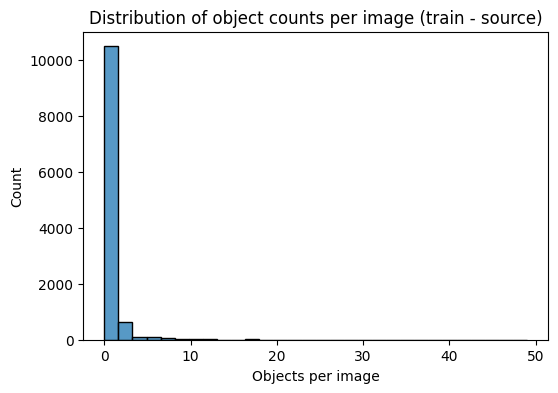

In [66]:
# Plot distribution: objects per image
plt.figure(figsize=(6,4))
sns.histplot(eda_train["per_image_counts"], bins=30, kde=False)
plt.xlabel("Objects per image")
plt.ylabel("Count")
plt.title("Distribution of object counts per image (train - source)")
plt.show()

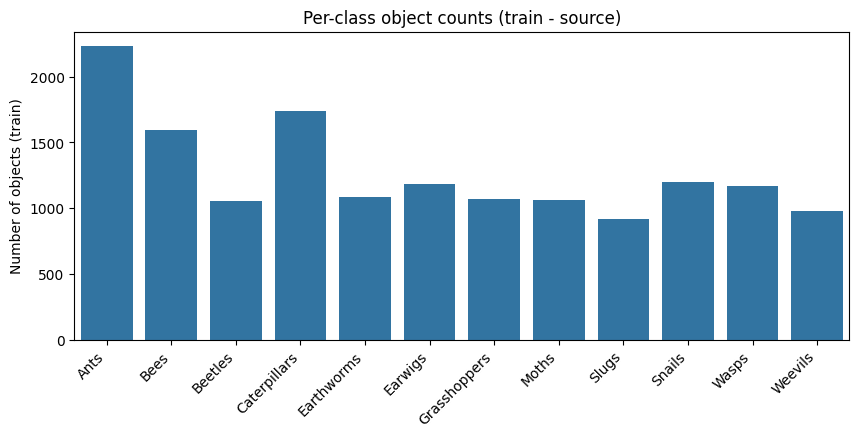

In [67]:
# Plot per-class counts (bar)
cls_idxs = list(range(NUM_CLASSES))
counts = [eda_train["per_class_counter"].get(i,0) for i in cls_idxs]
plt.figure(figsize=(10,4))
sns.barplot(x=[CLASS_NAMES[i] for i in cls_idxs], y=counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of objects (train)")
plt.title("Per-class object counts (train - source)")
plt.show()

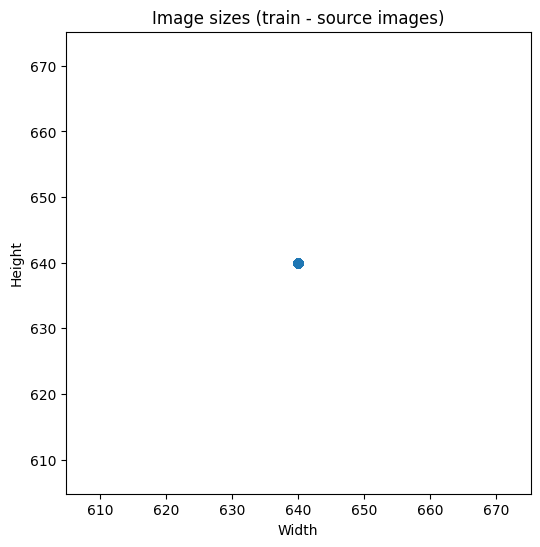

In [68]:
# Image size scatter
ws = [s[0] for s in eda_train["img_sizes"]]
hs = [s[1] for s in eda_train["img_sizes"]]
plt.figure(figsize=(6,6))
plt.scatter(ws, hs, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image sizes (train - source images)")
plt.show()

#### Samples Visualization

In [69]:
def visualize_samples(samples, max_cols=4):
    n = len(samples)
    if n == 0:
        print("No samples to visualize.")
        return
    cols = min(n, max_cols)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4*cols, 4*rows))
    for i, (img_path, label_or_mask_path, bboxes) in enumerate(samples):
        im_bgr = cv2.imread(img_path)
        if im_bgr is None:
            continue
        img = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        if bboxes:
            for (cls, cx, cy, bw, bh) in bboxes:
                x1 = int(cx - bw/2); y1 = int(cy - bh/2)
                x2 = int(cx + bw/2); y2 = int(cy + bh/2)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                cv2.putText(img, CLASS_NAMES[int(cls)], (max(x1,0), max(y1-6,0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        else:
            # try to overlay txt labels if txt exists
            if label_or_mask_path and str(label_or_mask_path).endswith(".txt"):
                with open(label_or_mask_path, "r") as f:
                    lines = [l.strip() for l in f.readlines() if l.strip()]
                # draw class ids on top-left
                for li,ln in enumerate(lines[:6]):
                    cv2.putText(img, ln, (6, 20 + 16*li), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img); plt.axis('off'); plt.title(Path(img_path).name)
    plt.tight_layout()
    plt.show()

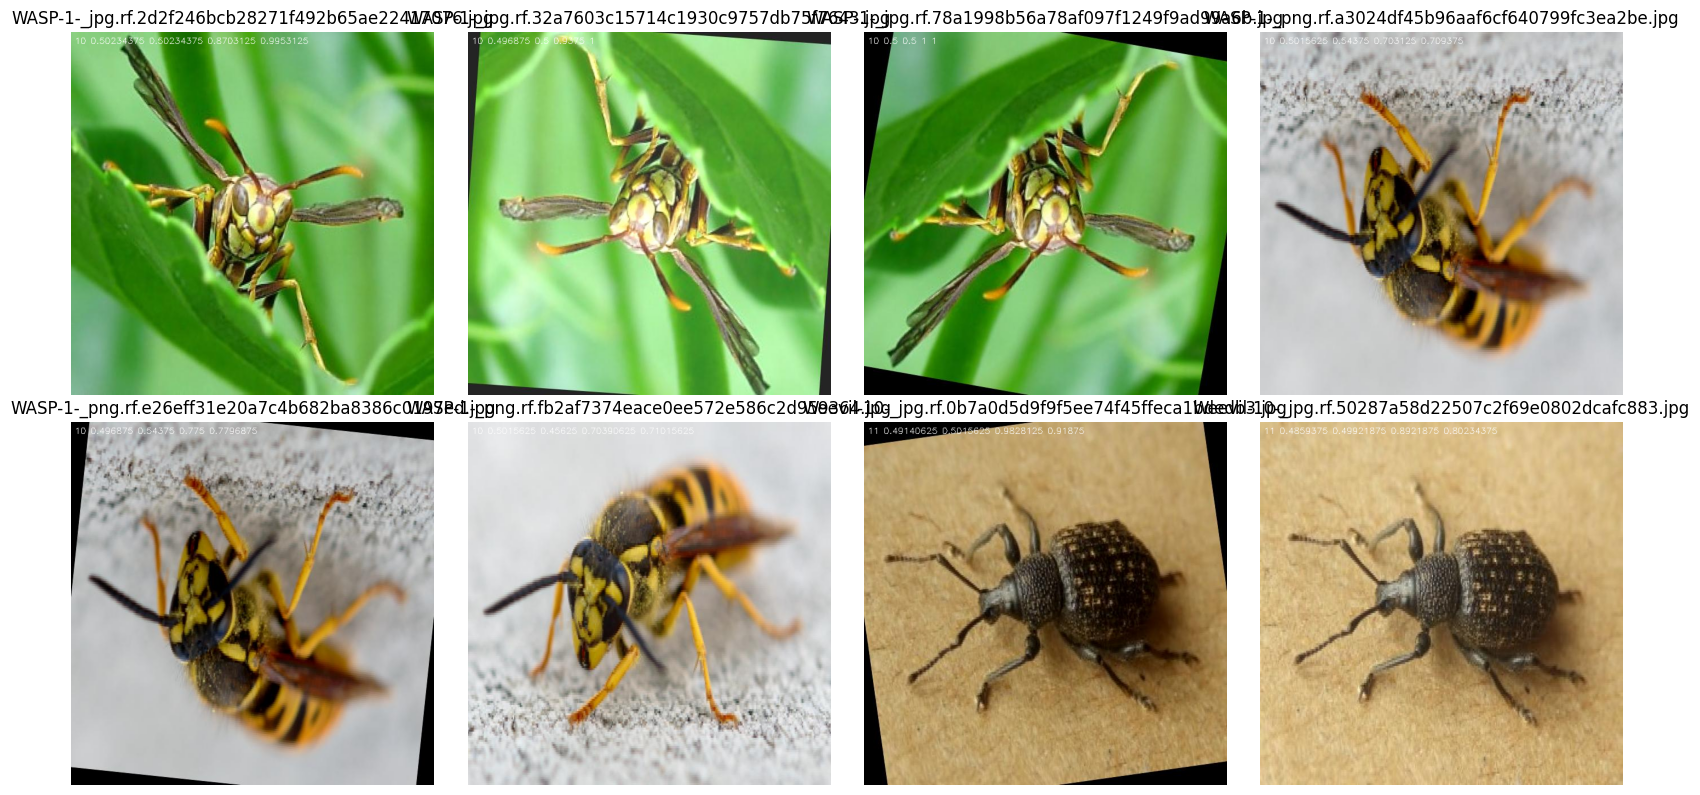

In [70]:
visualize_samples(eda_train.get("samples", []), max_cols=4)

#### Check Class Imbalance

In [71]:
total_objects = sum(counts)
if total_objects == 0:
    print("No detected objects in training set (source labels).")
else:
    imbalance = {CLASS_NAMES[i]: counts[i]/total_objects for i in range(NUM_CLASSES)}
    print("Top 5 classes by proportion:")
    for k,v in sorted(imbalance.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {k}: {v:.3f}")

Top 5 classes by proportion:
  Ants: 0.146
  Caterpillars: 0.114
  Bees: 0.104
  Snails: 0.078
  Earwigs: 0.077


#### Export Summary

In [72]:
summary_csv = "train_image_object_counts.csv"

In [73]:
with open(summary_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path","object_count"])
    for idx, pair in enumerate(train_pairs):
        cnt = eda_train["per_image_counts"][idx] if idx < len(eda_train["per_image_counts"]) else 0
        writer.writerow([pair[0], cnt])
print("Wrote", summary_csv)

Wrote train_image_object_counts.csv


### Model Training

In [74]:
from ultralytics import YOLO
import torch

# Choose model: "yolov8n.pt" (small) or a local checkpoint.
MODEL = "yolov8n.pt"
yolo = YOLO(MODEL)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Initialize Batch Size

In [75]:
batch_size = 16
if not torch.cuda.is_available():
    print("CUDA not available — reducing batch size to 4 and using CPU.")
    batch_size = 4

In [76]:
# Train (adjust epochs, imgsz as needed)
yolo.train(data="data.yaml", epochs=30, imgsz=640, batch=batch_size, project="yolov8_pests", name="exp1")

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a0b34df9a00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

### Model Prediction

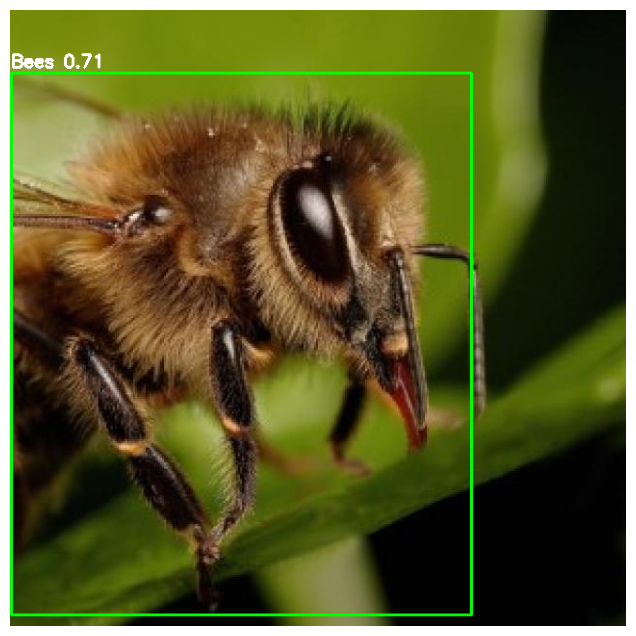

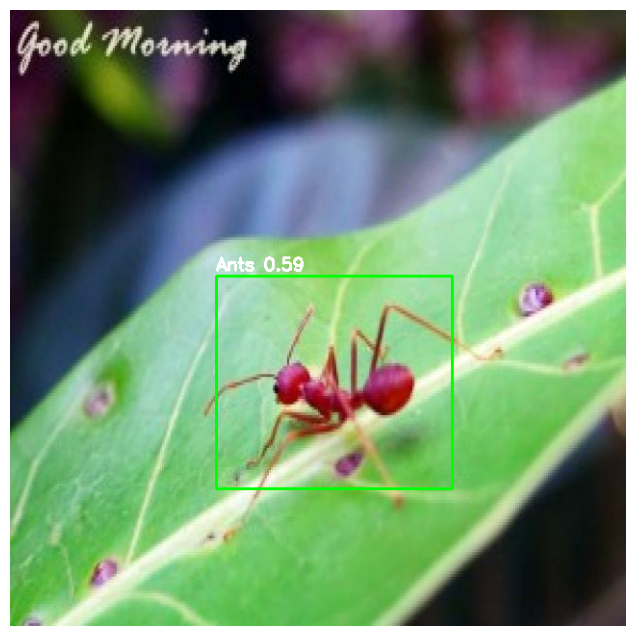

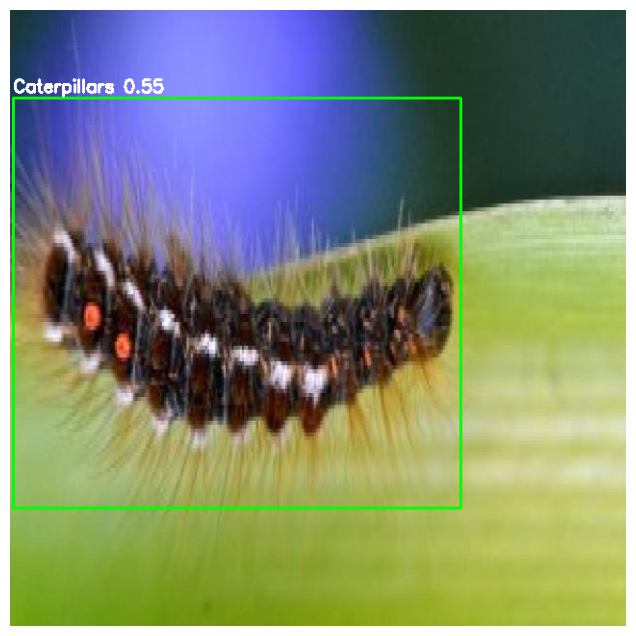

In [78]:
# After training, ultralytics saves best weights under runs/train/exp1/weights
weights_dir = Path("/kaggle/working/runs/detect/yolov8_pests/exp1/weights")
best_weights = weights_dir / "best.pt"
if not best_weights.exists():
    best_weights = weights_dir / "last.pt"
if not best_weights.exists():
    print("No trained weights found in runs/train/exp1/weights — check training logs")
else:
    model = YOLO(str(best_weights))

    def predict_and_visualize(image_path, conf=0.25, iou=0.45):
        res = model.predict(source=str(image_path), conf=conf, iou=iou, imgsz=640, save=False, verbose=False)
        if len(res) == 0:
            im = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
            plt.imshow(im); plt.axis('off'); plt.title("No detections"); plt.show()
            return
        r = res[0]
        im_bgr = cv2.imread(image_path)
        if im_bgr is None:
            return
        im = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
        boxes = getattr(r, "boxes", None)
        if boxes is None or len(boxes) == 0:
            plt.imshow(im); plt.axis('off'); plt.title("No detections"); plt.show(); return
        for box in boxes:
            try:
                xyxy = box.xyxy.cpu().numpy().astype(int).flatten()
                cls = int(box.cls.cpu().numpy().item())
                confs = float(box.conf.cpu().numpy().item())
            except Exception:
                xyxy = np.array(box.xyxy).astype(int).flatten()
                cls = int(box.cls)
                confs = float(box.conf)
            x1,y1,x2,y2 = int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])
            cv2.rectangle(im, (x1,y1), (x2,y2), (0,255,0), 2)
            txt = f"{CLASS_NAMES[cls]} {confs:.2f}" if 0 <= cls < NUM_CLASSES else f"{cls} {confs:.2f}"
            cv2.putText(im, txt, (x1, max(y1-6,0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        plt.figure(figsize=(10,8)); plt.imshow(im); plt.axis('off'); plt.show()

    # Example usage: visualize a trained model prediction on a few validation images (source)
    test_images = list((SRC_ROOT/"valid"/"images").glob("*"))[:3]
    for t in test_images:
        predict_and_visualize(str(t))